In [1]:
pip install pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel(r"C:\Users\Admin\Downloads\IPL Dataset.xlsm")
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,HUNDREAD,FIFTY,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Jersey No      133 non-null    int64  
 1   Player         133 non-null    object 
 2   Matches        133 non-null    int64  
 3   Inns           133 non-null    int64  
 4   Not Out        133 non-null    int64  
 5   Runs           133 non-null    int64  
 6   Highest Score  133 non-null    object 
 7   Avg            133 non-null    float64
 8   Balls faced    133 non-null    int64  
 9   Strike rate    133 non-null    float64
 10  HUNDREAD       133 non-null    int64  
 11  FIFTY          133 non-null    int64  
 12  4s             133 non-null    int64  
 13  6s             133 non-null    int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 14.7+ KB


Jersey No        0
Player           0
Matches          0
Inns             0
Not Out          0
Runs             0
Highest Score    0
Avg              0
Balls faced      0
Strike rate      0
HUNDREAD         0
FIFTY            0
4s               0
6s               0
dtype: int64

In [5]:
##Q1. What is the maximum number of matches played by an individual player in a season? Print the player 
# name along with the number of matched played

In [6]:



max_matches = df['Matches'].max()
result = df[df['Matches'] == max_matches][['Player', 'Matches']]

print("Player(s) with maximum matches:")
print(result)


Player(s) with maximum matches:
            Player  Matches
1   Shikhar Dhawan       17
3     Shreyas Iyer       17
19  Marcus Stoinis       17
67   Kagiso Rabada       17


In [7]:
##Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [8]:

df.columns = df.columns.str.strip()

result = df[df['FIFTY'] >= 2].sort_values('Avg', ascending=False)[['Player', 'Avg']].head(2) 

print(result)


             Player    Avg
36  Wriddhiman Saha  71.33
4      Ishan Kishan  57.33


In [9]:
#Q3. Create 2 new columns based on Player name. First column will have first name and second column will have last name.
#Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [10]:
df[['First Name', 'Last Name']] = df['Player'].str.split(' ', n=1, expand=True)

print(df[['Player', 'First Name', 'Last Name']].head())



           Player First Name Last Name
0        KL Rahul         KL     Rahul
1  Shikhar Dhawan    Shikhar    Dhawan
2    David Warner      David    Warner
3    Shreyas Iyer    Shreyas      Iyer
4    Ishan Kishan      Ishan    Kishan


In [11]:
#Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [12]:
# Highest Score column to string (safe)
df['Highest Score'] = df['Highest Score'].astype(str)

df['Cleaned_Highest_score'] = df['Highest Score'].str.replace('*', '', regex=False)

# cleaned column to integer
df['Cleaned_Highest_score'] = pd.to_numeric(df['Cleaned_Highest_score'], errors='coerce')

print(df[['Highest Score', 'Cleaned_Highest_score']].head())


  Highest Score  Cleaned_Highest_score
0          132*                    132
1          106*                    106
2           85*                     85
3           88*                     88
4            99                     99


In [13]:
#Q5. Print the total number of centuries scored in the entire season

In [14]:
# Condition: Runs >= 100 means a century
total_centuries = df[df['Runs'] >= 100].shape[0]

print("Total Centuries in the whole season:", total_centuries)


Total Centuries in the whole season: 58


In [15]:
# Q6. Print all the player names whose strike rate is less than the average strike rate of all players in entire season. 
# Print the player name, his strike rate and average strike rate.

In [16]:
avg_sr = df['Strike rate'].mean()

df[df['Strike rate'] < avg_sr][['Player', 'Strike rate']].assign(
    Average_Strike_Rate = avg_sr
)


,Player,Strike rate,Average_Strike_Rate
51,Ajinkya Rahane,105.60,107.364737
55,Glenn Maxwell,101.88,107.364737
58,Vijay Shankar,101.04,107.364737
61,Josh Philippe,101.29,107.364737
62,Gurkeerat Singh,88.75,107.364737
65,Kedar Jadhav,93.93,107.364737
70,Yashasvi Jaiswal,90.90,107.364737
71,Shreyas Gopal,94.87,107.364737
77,Murali Vijay,74.41,107.364737
79,Chris Jordan,93.54,107.364737


In [17]:
#Q7. Please check the correlation between the features and create a heat map.

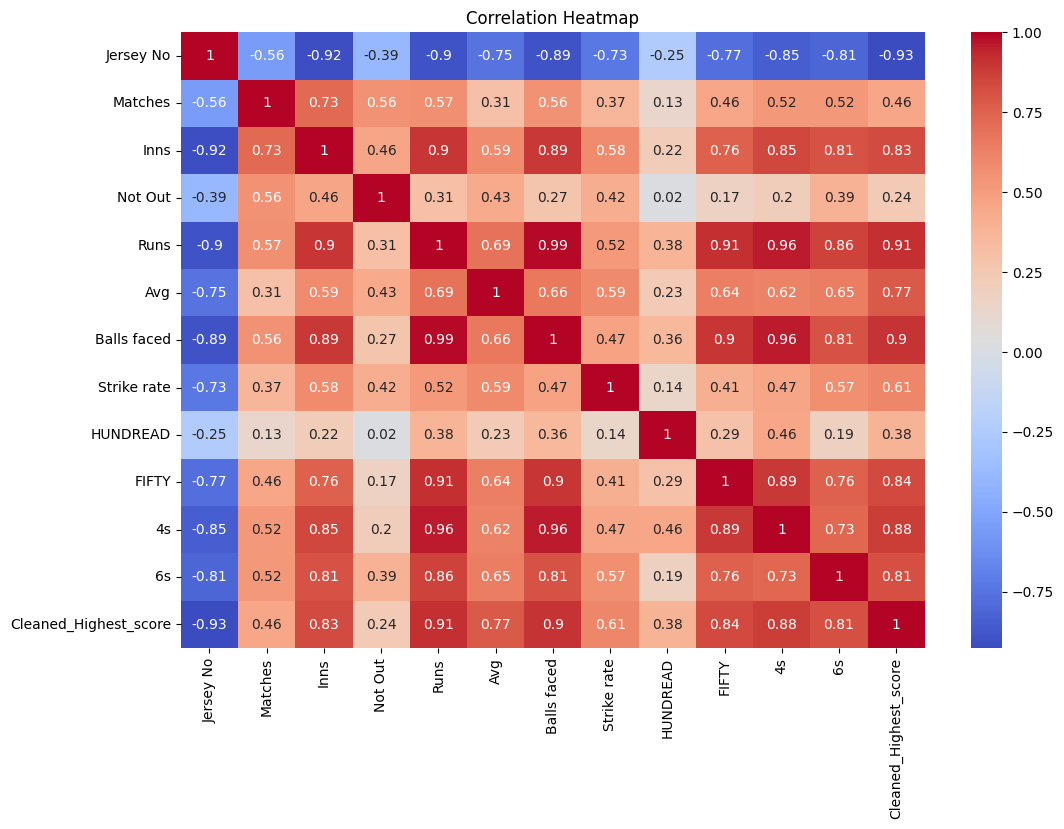

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
#Q8. Check the list of players who has an average greater than 50 as well strike rate above 125. Print player name, average and strike rate.

In [20]:
df[(df['Avg'] > 50) & (df['Strike rate'] > 125)][
    ['Player', 'Avg', 'Strike rate']
]


,Player,Avg,Strike rate
0,KL Rahul,55.83,129.34
4,Ishan Kishan,57.33,145.76
31,Kieron Pollard,53.60,191.42
36,Wriddhiman Saha,71.33,139.86
57,Deepak Hooda,101.00,142.25
60,Tom Curran,83.00,133.87


In [21]:

#Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced


In [22]:
df[(df['Avg'] > 40) & (df['Balls faced'] > 100)][
    ['Player', 'Avg', 'Balls faced']
]


,Player,Avg,Balls faced
0,KL Rahul,55.83,518
1,Shikhar Dhawan,44.14,427
4,Ishan Kishan,57.33,354
8,Virat Kohli,42.36,384
9,ABD Villiers,45.40,286
10,Faf Duplessis,40.81,319
14,Eoin Morgan,41.80,302
24,Kane Williamson,45.28,237
27,Chris Gayle,41.14,210
28,Ben Stokes,40.71,200


In [23]:
#Q10. Players who scored atleast one century in this season. Create visualization.

Players with Centuries:
            Player  HUNDREAD
1   Shikhar Dhawan         2
0         KL Rahul         1
13  Mayank Agarwal         1
28      Ben Stokes         1


NameError: name 'pllat' is not defined

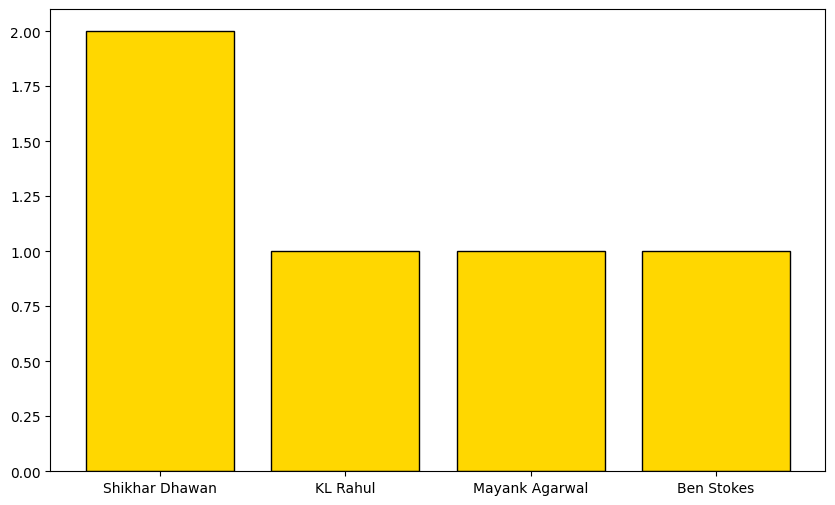

In [24]:



df.columns = df.columns.str.strip()

century_df = df[df['HUNDREAD'] >= 1].sort_values('HUNDREAD', ascending=False)

print("Players with Centuries:")
print(century_df[['Player', 'HUNDREAD']])


plt.figure(figsize=(10, 6))
plt.bar(century_df['Player'], century_df['HUNDREAD'], color='gold', edgecolor='black')


pllat.xbel('Player Name', fontsize=12)
plt.ylabel('Number of Centuries', fontsize=12)
plt.title('Players who scored at least one Century', fontsize=14)
plt.xticks(rotation=45) 

plt.show()


In [ ]:
#Q11. Players who scored atleast 4 half centuries in this season.

In [ ]:
df.columns = df.columns.str.strip()

result = df[df['FIFTY'] >= 4][['Plar'ye, 'FIFTY']]

print("Players with atleast 4 half centuries:")
print(result)


Players with atleast 4 half centuries:
              Player  FIFTY
0           KL Rahul      5
1     Shikhar Dhawan      4
2       David Warner      4
4       Ishan Kishan      4
5       Quinton Kock      4
6   Suryakumar Yadav      4
7   Devdutt Padikkal      5
9       ABD Villiers      5
10     Faf Duplessis      4


In [ ]:
#Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [ ]:
df.columns = df.columns.str.strip()

result = df[(df['4s'] > 45) & (df['6s'] > 10)][['Player', '4s', '6s']]

print("Players with > 45 boundaries and > 10 sixes:")
print(result)

Players with > 45 boundaries and > 10 sixes:
             Player  4s  6s
0          KL Rahul  58  23
1    Shikhar Dhawan  67  12
2      David Warner  52  14
5      Quinton Kock  46  22
6  Suryakumar Yadav  61  11


In [ ]:
##Q13. Plot a histogram of number of matches played in a season by players

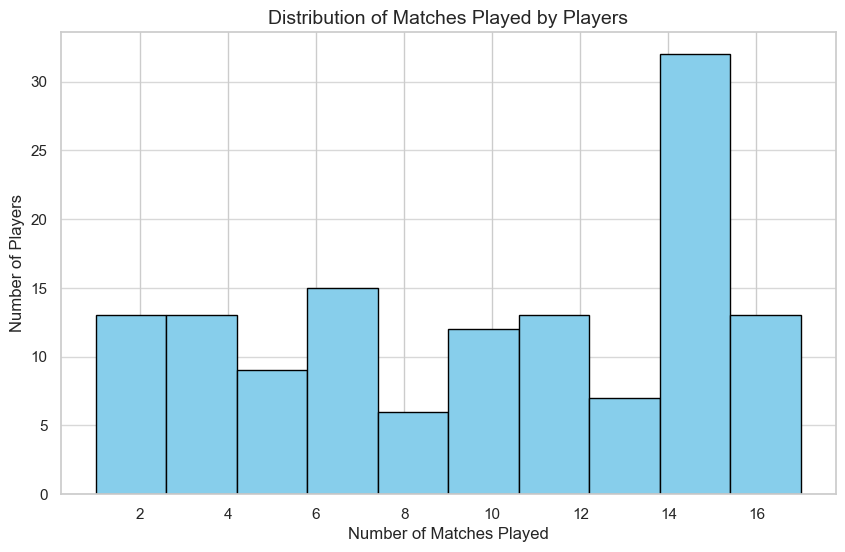

In [ ]:

# 1. Column namt.figure(figsize=(10, 6))
# 'bins' defes ke extra spaces hatayein (taaki error na aaye)
df.columns = df.columns.str.strip()

pline karta hai ki kitne groups mein data baantna hai
plt.hist(df['Matches'], bins=10, color='skyblue', edgecolor='black')

plt.xlabel('Number of Matches Played', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.title('Distribution of Matches Played by Players', fontsize=14)

plt.grid(axis='y', alpha=0.75)

plt.show()

In [ ]:
##Q14. Plot the histogram of balls faced by players.

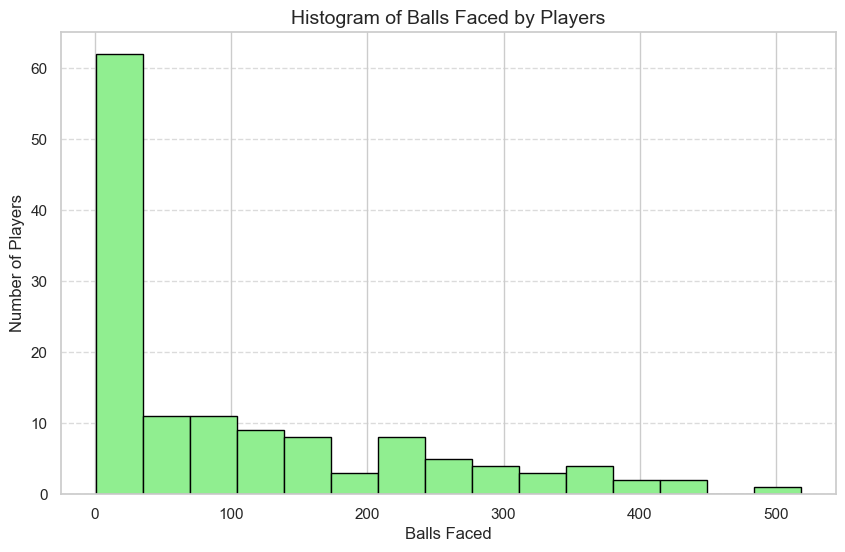

In [ ]:
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 6))
# 'Balls faced' column ka data use karein
plt.hist(df['Balls faced'], bins=15, color='lightgreen', edgecolor='black')

plt.xlabel('Balls Faced', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.title('Histogram of Balls Faced by Players', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
##Q15. Top 12 players with most runs in a season.

In [ ]:
df.columns = df.columns.str.strip()

top_12_scorers = df.sort_values('Runs', ascending=False)[['Player', 'Runs']].head(12)


print("Top 12 players with most runs in the season:")
print(top_12_scorers)

Top 12 players with most runs in the season:
              Player  Runs
0           KL Rahul   670
1     Shikhar Dhawan   618
2       David Warner   548
3       Shreyas Iyer   519
4       Ishan Kishan   516
5       Quinton Kock   503
6   Suryakumar Yadav   480
7   Devdutt Padikkal   473
8        Virat Kohli   466
9       ABD Villiers   454
10     Faf Duplessis   449
11      Shubman Gill   440


In [ ]:
#Q16. Print the players who played the match but didn't get the batting.

In [ ]:
df.columns = df.columns.str.strip()

not_batted = df[df['Inns'] == 0][['Player', 'Matches', 'Inns']]


print("Players who played but didn't get to bat:")
print(not_batted)

Players who played but didn't get to bat:
Empty DataFrame
Columns: [Player, Matches, Inns]
Index: []


In [ ]:
##Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [ ]:
n
df.columns = df.columns.str.strip()

# 2. Naya column 'Boundary_Percentage' banayein
# Formula: ((4s * 4) + (6s * 6)) / Total Runs * 100
df['Boundary_Percentage'] = ((df['4s'] * 4) + (df['6s'] * 6)) / df['Runs'] * 100

top_5_boundary_players = df.sort_values('Boundary_Percentage', ascending=False)[['Player', 'Runs', 'Boundary_Percentage']].head(5)

print("Top 5 players with maximum percentage of runs in boundaries:")
print(top_5_boundary_players)

Top 5 players with maximum percentage of runs in boundaries:
            Player  Runs  Boundary_Percentage
109     Andrew Tye     6           100.000000
48   Andre Russell   117            76.923077
74    Chris Morris    34            76.470588
29   Hardik Pandya   281            73.309609
47    Sunil Narine   121            72.727273


In [ ]:
##Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).



In [ ]:

df.columns = df.columns.str.strip()


# find % Formula: (Not Out / Inns) * 100
df['Not_Out_Percentage'] = (df['Not Out'] / df['Inns']) * 100


top_5_not_out = df.sort_values('Not_Out_Percentage', ascending=False)[['Player', 'Not Out', 'Inns', 'Not_Out_Percentage']].head(5)

print("Top 5 players with maximum Not Out percentage:")
print(top_5_not_out)

Top 5 players with maximum Not Out percentage:
              Player  Not Out  Inns  Not_Out_Percentage
113  Dhawal Kulkarni        1     1               100.0
116     Rahul Chahar        1     1               100.0
115  Prasidh Krishna        2     2               100.0
62   Gurkeerat Singh        5     5               100.0
68   Lockie Ferguson        2     2               100.0


In [ ]:
#Q19. Create visualization of top 10 players with highest number of sixes


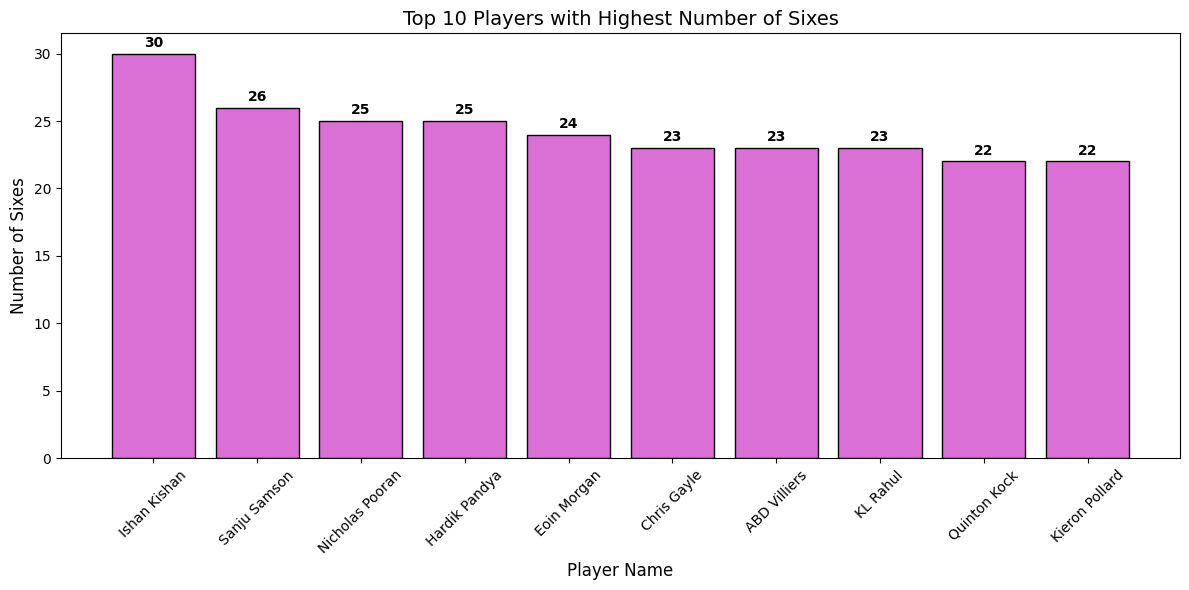

In [ ]:


# 1. Column names ke extra spaces hatayein
df.columns = df.columns.str.strip()

# 2. '6s' ke hisaab se sort karke top 10 players nikalein
top_10_sixes = df.sort_values('6s', ascending=False).head(10)

# 3. Visualization (Bar Chart)
plt.figure(figsize=(12, 6))
plt.bar(top_10_sixes['Player'], top_10_sixes['6s'], color='orchid', edgecolor='black')

# Labels aur Title
plt.xlabel('Player Name', fontsize=12)
plt.ylabel('Number of Sixes', fontsize=12)
plt.title('Top 10 Players with Highest Number of Sixes', fontsize=14)

# Naam ko thoda rotate karein taaki clear dikhein
plt.xticks(rotation=45)

# Values ko bars ke upar dikhane ke liye
for i, value in enumerate(top_10_sixes['6s']):
    plt.text(i, value + 0.5, str(int(value)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.



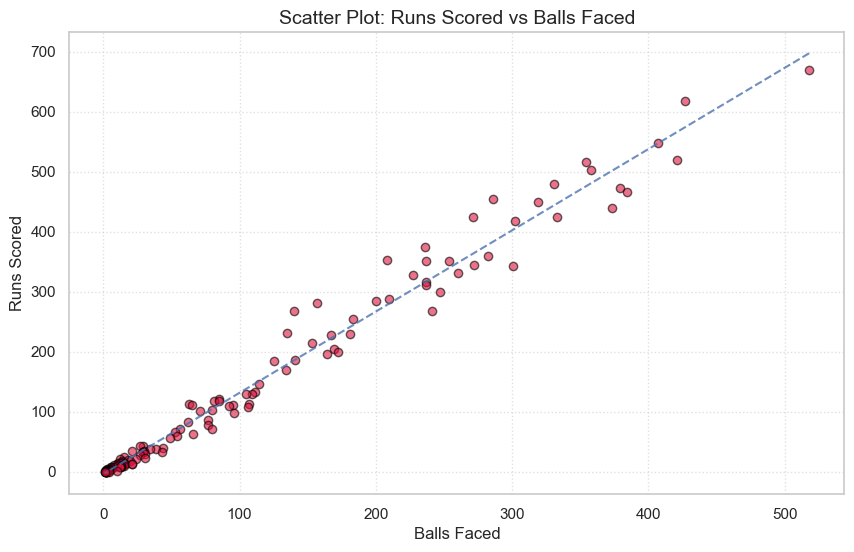

Relationship (Correlation Coefficient): 0.99


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Column names ke extra spaces hatayein
df.columns = df.columns.str.strip()

# 2. create scatter plot

plt.figure(figsize=(10, 6))
plt.scatter(df['Balls faced'], df['Runs'], color='crimson', alpha=0.6, edgecolor='black')

# 3. Trendline (Relationship dikhane ke liye)
# Ye optional hai, par isse relation saaf dikhta hai
z = np.polyfit(df['Balls faced'], df['Runs'], 1)
p = np.poly1d(z)
plt.plot(df['Balls faced'], p(df['Balls faced']), "b--", alpha=0.8)

# 4. Labels aur Title
plt.xlabel('Balls Faced', fontsize=12)
plt.ylabel('Runs Scored', fontsize=12)
plt.title('Scatter Plot: Runs Scored vs Balls Faced', fontsize=14)

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Correlation nikalne ke liye (Relationship check)
correlation = df['Balls faced'].corr(df['Runs'])
print(f"Relationship (Correlation Coefficient): {correlation:.2f}")